## Exercise 2: Generate the Feature Importance of the Target Variable and Carry Out EDA

In [20]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style="ticks")

df = pd.read_csv('bank.csv', sep=';')


['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'y']


C:\Users\MouKexin\AppData\Local\Temp\ipykernel_22140\720086106.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].replace({


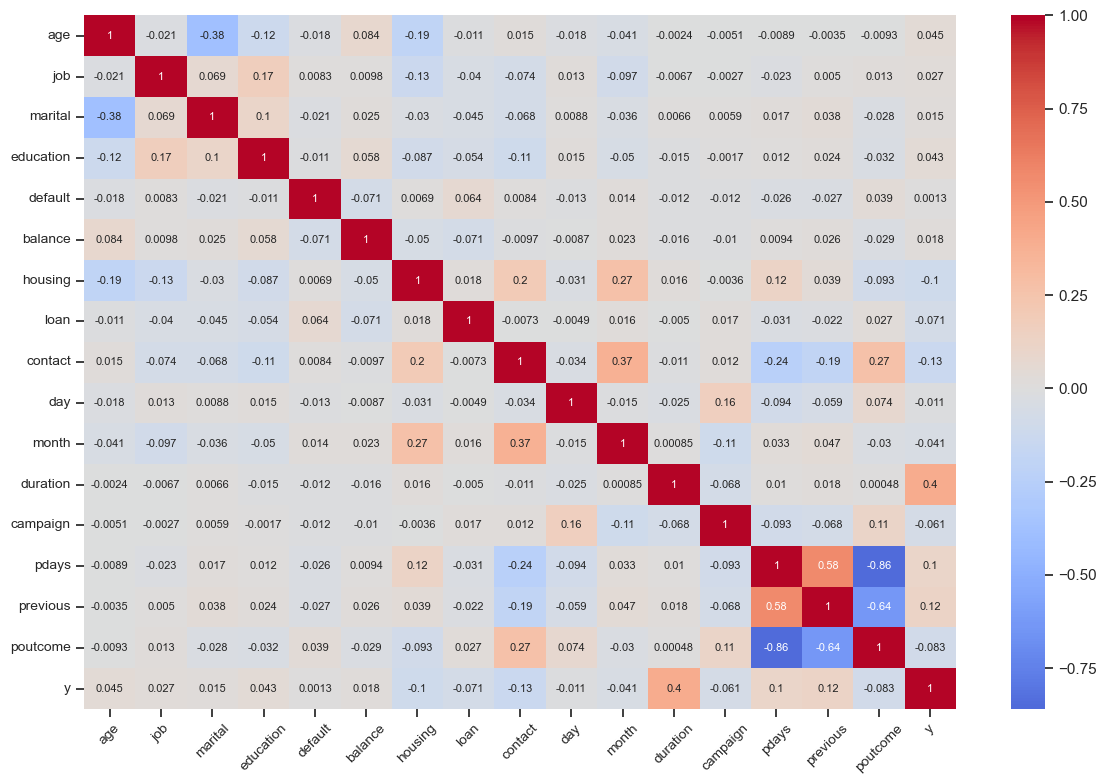

In [14]:
binary_columns = ['y', 'default', 'housing', 'loan']
for col in binary_columns:
    if col in df.columns:
        df[col] = df[col].replace({
            'yes': 1,
            'no': 0
        })

# df['y'].replace(['yes','no'],[1,0],inplace=True)
# df['default'].replace(['yes','no'],[1,0],inplace=True)
# df['housing'].replace(['yes','no'],[1,0],inplace=True)
# df['loan'].replace(['yes','no'],[1,0],inplace=True)

from sklearn.preprocessing import LabelEncoder

remaining_str_cols = df.select_dtypes(include=['object']).columns.tolist()

for col in remaining_str_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))

corr_df = df.corr()

sns.heatmap(
    corr_df,
    xticklabels=corr_df.columns.values,
    yticklabels=corr_df.columns.values,
    annot=True,
    annot_kws={'size': 8},
    cmap='coolwarm',
    center=0
)

heat_map = plt.gcf()
heat_map.set_size_inches(12, 8)

plt.xticks(fontsize=10, rotation=45)
plt.yticks(fontsize=10, rotation=0)
plt.tight_layout()
plt.show()

In [16]:
from sklearn.ensemble import RandomForestClassifier
from boruta import BorutaPy

for col_name in df.columns:
    if(df[col_name].dtype == 'object'):
        df[col_name]= df[col_name].astype('category')
        df[col_name] = df[col_name].cat.codes

X = df.drop(['y'], axis=1).values
Y = df['y'].values

rfc = RandomForestClassifier(n_estimators=200, n_jobs=4, class_weight='balanced', max_depth=6)
boruta_selector = BorutaPy(rfc, n_estimators='auto', verbose=2)
n_train = len(X)

boruta_selector.fit(X, Y)

Iteration: 	1 / 100
Confirmed: 	0
Tentative: 	16
Rejected: 	0
Iteration: 	2 / 100
Confirmed: 	0
Tentative: 	16
Rejected: 	0
Iteration: 	3 / 100
Confirmed: 	0
Tentative: 	16
Rejected: 	0
Iteration: 	4 / 100
Confirmed: 	0
Tentative: 	16
Rejected: 	0
Iteration: 	5 / 100
Confirmed: 	0
Tentative: 	16
Rejected: 	0
Iteration: 	6 / 100
Confirmed: 	0
Tentative: 	16
Rejected: 	0
Iteration: 	7 / 100
Confirmed: 	0
Tentative: 	16
Rejected: 	0
Iteration: 	8 / 100
Confirmed: 	8
Tentative: 	1
Rejected: 	7
Iteration: 	9 / 100
Confirmed: 	8
Tentative: 	1
Rejected: 	7
Iteration: 	10 / 100
Confirmed: 	8
Tentative: 	1
Rejected: 	7
Iteration: 	11 / 100
Confirmed: 	8
Tentative: 	1
Rejected: 	7
Iteration: 	12 / 100
Confirmed: 	8
Tentative: 	1
Rejected: 	7
Iteration: 	13 / 100
Confirmed: 	8
Tentative: 	1
Rejected: 	7
Iteration: 	14 / 100
Confirmed: 	8
Tentative: 	1
Rejected: 	7
Iteration: 	15 / 100
Confirmed: 	8
Tentative: 	1
Rejected: 	7
Iteration: 	16 / 100
Confirmed: 	8
Tentative: 	1
Rejected: 	7
Iteration:

BorutaPy(estimator=RandomForestClassifier(class_weight='balanced', max_depth=6,
                                          n_estimators=70, n_jobs=4,
                                          random_state=RandomState(MT19937) at 0x2E3EB730E40),
         n_estimators='auto',
         random_state=RandomState(MT19937) at 0x2E3EB730E40, verbose=2)

,features,rank
0,age,1
1,balance,1
2,previous,1
3,poutcome,1
4,pdays,1
5,duration,1
6,month,1
7,contact,1
8,housing,2
9,day,3


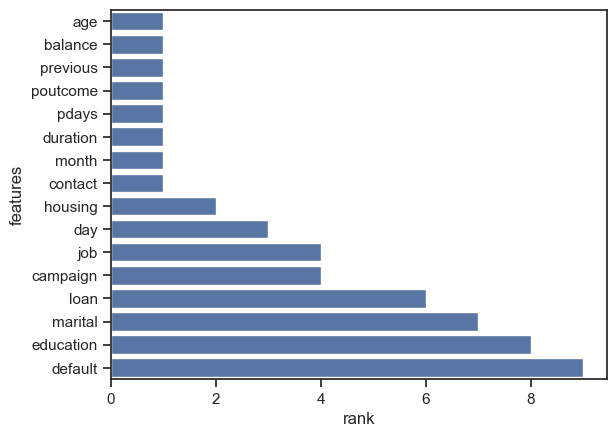

In [17]:
feature_df = pd.DataFrame(df.drop(['y'], axis=1).columns.tolist(), columns=['features'])
feature_df['rank']=boruta_selector.ranking_
feature_df = feature_df.sort_values('rank', ascending=True).reset_index(drop=True)
sns.barplot(x='rank',y='features',data=feature_df)
feature_df